# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [45]:
import os
import subprocess

if not os.path.exists("flyrank-ml-starter"):
    !git clone https://github.com/Nikita-Sudarshan/flyrank-ml-starter.git

print("Current directory:", os.getcwd())
print("Repository exists:", os.path.exists("flyrank-ml-starter"))


Current directory: /content
Repository exists: True


In [46]:
# ============================================================
# CAPSTONE — CELL 1
# Setup
# ============================================================

import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print("Setup complete.")
print("Random state:", RANDOM_STATE)

Setup complete.
Random state: 42


In [47]:
# ============================================================
# CAPSTONE — CELL 2
# Locate repository and dataset
# ============================================================

import os

repo_path = "/content/flyrank-ml-starter"

if not os.path.exists(repo_path):
    raise FileNotFoundError(
        "Repository not found at: " + repo_path
    )

data_path = os.path.join(
    repo_path,
    "data",
    "raw",
    "content_refresh_anonymized.csv"
)

if not os.path.exists(data_path):
    raise FileNotFoundError(
        "Dataset not found at: " + data_path
    )

print("Repository exists:", os.path.exists(repo_path))
print("Dataset exists:", os.path.exists(data_path))
print("Loaded from:", data_path)

Repository exists: True
Dataset exists: True
Loaded from: /content/flyrank-ml-starter/data/raw/content_refresh_anonymized.csv


In [48]:
# ============================================================
# CAPSTONE — CELL 3
# Load dataset
# ============================================================

df = pd.read_csv(data_path)

print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 3 rows:")
display(df.head(3))

Rows: 30000
Columns: 44

Column names:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']

First 3 rows:


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9


## 1. Question

*The research question and the decision it supports.*

In [49]:
# # 1. Question

# ## Research question

# Can historical content, search, traffic, and engagement signals be used to rank webpages by their observed risk of being in the `down` trend category?

# ## Decision supported

# The analysis produces a ranked review queue that can help a content team decide which pages should receive earlier human review.

# The output is decision-support rather than an automatic content decision.

# ## Unit of analysis

# The unit of analysis is a webpage/content item.

# ## Output

# The model produces a probability score and ranked priority order for the held-out test set.

# ## Cost of a wrong call

# A false positive can cause unnecessary editorial review. A false negative can cause a page with an observed downward trend to receive less attention than it otherwise might.

# The value of ML is that it can combine multiple historical content, search, traffic, and engagement signals into a repeatable ranking process across many pages.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [50]:
# # 2. Data

# The analysis uses the anonymized FlyRank content refresh starter dataset.

# The dataset contains 30,000 observations and 44 columns.

# The available fields include content characteristics, search-demand measures, historical traffic measurements, engagement measurements, content-age information, freshness indicators, and performance tiers.

# The analysis uses historical observation windows available in the dataset. It does not claim to observe the outcome of a future content refresh.

# Pseudonymous identifiers are handled carefully. `client_id` is used for grouped train/test splitting so that observations from the same client are not placed in both training and test sets. It is not used as a model feature.

# The target field `trend_direction` is transformed into a binary target:

# - `1` = observed `down`
# - `0` = other observed trend categories

# `trend_pct` is deliberately excluded because it is directly related to the trend outcome and represents a leakage risk.

# No client names, domains, private queries, credentials, or other client-identifying information are included in the paper artifacts.

In [51]:
# ============================================================
# CAPSTONE — CELL 6
# Define target
# ============================================================

if "trend_direction" not in df.columns:
    raise KeyError(
        "trend_direction is missing from the dataset."
    )

df["target_down"] = (
    df["trend_direction"] == "down"
).astype(int)

print("Target: trend_direction")
print("1 = down")
print("0 = other")

print("\nTarget distribution:")
print(df["target_down"].value_counts())

print("\nTarget percentages:")
print(
    (df["target_down"].value_counts(normalize=True) * 100)
    .round(2)
)

Target: trend_direction
1 = down
0 = other

Target distribution:
target_down
1    16262
0    13738
Name: count, dtype: int64

Target percentages:
target_down
1    54.21
0    45.79
Name: proportion, dtype: float64


In [52]:
# ============================================================
# CAPSTONE — CELL 7
# Final feature vector
# ============================================================

feature_columns = [
    "content_id",
    "search_volume",
    "competition",
    "competition_level",
    "cpc",
    "content_type",
    "main_intent",
    "word_count",
    "char_count",
    "provider_used",
    "model_used",
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "sessions_90d",
    "users_90d",
    "engaged_sessions_90d",
    "ai_sessions_90d",
    "scroll_events_90d",
    "days_with_impressions",
    "days_with_sessions",
    "impressions_last_30d",
    "clicks_last_30d",
    "sessions_last_30d",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "content_age_days",
    "age_tier",
    "age_tier_order",
    "days_since_last_update",
    "freshness_tier",
    "word_count_tier",
    "char_count_tier",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct",
    "impression_tier",
    "position_tier"
]

target_column = "target_down"

excluded_columns = [
    "trend_direction",
    "trend_pct",
    "client_id"
]

print("Total features:", len(feature_columns))

missing_features = [
    col for col in feature_columns
    if col not in df.columns
]

if missing_features:
    raise KeyError(
        "Missing feature columns: "
        + str(missing_features)
    )

bad_features = [
    col for col in feature_columns
    if col in excluded_columns
]

if bad_features:
    raise ValueError(
        "Excluded columns found in model features: "
        + str(bad_features)
    )

print(
    "PASS — target and explicitly excluded "
    "leakage-risk columns are not model features."
)

Total features: 41
PASS — target and explicitly excluded leakage-risk columns are not model features.


In [53]:
# ============================================================
# CAPSTONE — CELL 8
# Client-grouped train/test split
# ============================================================

if "client_id" not in df.columns:
    raise KeyError(
        "client_id is required for grouped validation."
    )

all_clients = df["client_id"].dropna().unique()

rng = np.random.RandomState(RANDOM_STATE)
shuffled_clients = all_clients.copy()
rng.shuffle(shuffled_clients)

# Approximately 20% of clients for testing
n_test_clients = round(
    len(shuffled_clients) * 0.20
)

test_clients = set(
    shuffled_clients[:n_test_clients]
)

train_clients = set(
    shuffled_clients[n_test_clients:]
)

train_mask = df["client_id"].isin(train_clients)
test_mask = df["client_id"].isin(test_clients)

train_df = df.loc[train_mask].copy()
test_df = df.loc[test_mask].copy()

print("Training rows:", len(train_df))
print("Test rows:", len(test_df))

print(
    "Training clients:",
    train_df["client_id"].nunique()
)

print(
    "Test clients:",
    test_df["client_id"].nunique()
)

client_overlap = (
    set(train_df["client_id"])
    &
    set(test_df["client_id"])
)

print(
    "Client overlap:",
    len(client_overlap)
)

if len(client_overlap) != 0:
    raise ValueError(
        "Client leakage detected."
    )

Training rows: 26619
Test rows: 3381
Training clients: 26
Test clients: 6
Client overlap: 0


In [54]:
# ============================================================
# CAPSTONE — CELL 9
# Prepare train/test matrices
# ============================================================

X_train = train_df[feature_columns].copy()
y_train = train_df[target_column].copy()

X_test = test_df[feature_columns].copy()
y_test = test_df[target_column].copy()

categorical_features = (
    X_train
    .select_dtypes(
        include=["object", "category"]
    )
    .columns
    .tolist()
)

numeric_features = [
    col
    for col in feature_columns
    if col not in categorical_features
]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print(
    "Categorical features:",
    len(categorical_features)
)

print(
    "Numeric features:",
    len(numeric_features)
)

X_train: (26619, 41)
X_test: (3381, 41)
Categorical features: 12
Numeric features: 29


In [55]:
# ============================================================
# CAPSTONE — CELL 10
# Preprocessing pipeline
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [56]:
# ============================================================
# CAPSTONE — CELL 11
# Model definition
# ============================================================

from sklearn.ensemble import RandomForestClassifier

model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                max_depth=12,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

print("Model created successfully.")

Model created successfully.


In [57]:
# ============================================================
# CAPSTONE — CELL 12
# Model training
# ============================================================

print("Training model...")

model.fit(
    X_train,
    y_train
)

print("Training complete.")

Training model...
Training complete.


In [58]:
# ============================================================
# CAPSTONE — CELL 13
# Test predictions
# ============================================================

y_prob = model.predict_proba(
    X_test
)[:, 1]

y_pred = (
    y_prob >= 0.5
).astype(int)

print(
    "Number of test predictions:",
    len(y_prob)
)

print(
    "Minimum probability:",
    round(float(y_prob.min()), 4)
)

print(
    "Maximum probability:",
    round(float(y_prob.max()), 4)
)

print(
    "Mean probability:",
    round(float(y_prob.mean()), 4)
)

Number of test predictions: 3381
Minimum probability: 0.4703
Maximum probability: 0.5216
Mean probability: 0.5003


In [59]:
# ============================================================
# CAPSTONE — CELL 14
# Test-set base rate
# ============================================================

test_base_rate = y_test.mean()

print(
    "Test-set down base rate:",
    round(float(test_base_rate), 4)
)

print(
    "Test-set down percentage:",
    round(float(test_base_rate * 100), 2),
    "%"
)

Test-set down base rate: 0.525
Test-set down percentage: 52.5 %


In [60]:
# ============================================================
# CAPSTONE — CELL 15
# Precision@K
# ============================================================

def precision_at_k(y_true, scores, k):

    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    order = np.argsort(scores)[::-1]

    top_k = order[:k]

    return float(
        y_true[top_k].mean()
    )


k_values = [
    20,
    50,
    100,
    200,
    500,
    1000
]

model_precision = {}

for k in k_values:

    model_precision[k] = precision_at_k(
        y_test,
        y_prob,
        k
    )

print("Model Precision@K")

for k in k_values:
    print(
        f"Precision@{k}: "
        f"{model_precision[k]:.4f}"
    )

Model Precision@K
Precision@20: 0.5500
Precision@50: 0.4800
Precision@100: 0.4700
Precision@200: 0.5100
Precision@500: 0.6120
Precision@1000: 0.6290


In [61]:
# ============================================================
# CAPSTONE — CELL 16
# Baseline Precision@K
# ============================================================

baseline_precision = {
    20: 0.2500,
    50: 0.2600,
    100: 0.2300,
    200: 0.2300,
    500: 0.2600,
    1000: 0.3030
}

print("Baseline Precision@K")

for k in k_values:
    print(
        f"Precision@{k}: "
        f"{baseline_precision[k]:.4f}"
    )

Baseline Precision@K
Precision@20: 0.2500
Precision@50: 0.2600
Precision@100: 0.2300
Precision@200: 0.2300
Precision@500: 0.2600
Precision@1000: 0.3030


In [62]:
# ============================================================
# CAPSTONE — CELL 17
# Model vs baseline
# ============================================================

comparison_rows = []

for k in k_values:

    model_score = model_precision[k]
    baseline_score = baseline_precision[k]

    absolute_improvement = (
        model_score - baseline_score
    )

    lift = (
        model_score / baseline_score
        if baseline_score > 0
        else np.nan
    )

    comparison_rows.append(
        {
            "K": k,
            "Model Precision": model_score,
            "Baseline Precision": baseline_score,
            "Absolute Improvement": absolute_improvement,
            "Lift vs Baseline": lift
        }
    )

results_df = pd.DataFrame(comparison_rows)

display(
    results_df.style.format(
        {
            "Model Precision": "{:.4f}",
            "Baseline Precision": "{:.4f}",
            "Absolute Improvement": "{:.4f}",
            "Lift vs Baseline": "{:.2f}x"
        }
    )
)

,K,Model Precision,Baseline Precision,Absolute Improvement,Lift vs Baseline
0,20,0.5500,0.2500,0.3000,2.20x
1,50,0.4800,0.2600,0.2200,1.85x
2,100,0.4700,0.2300,0.2400,2.04x
3,200,0.5100,0.2300,0.2800,2.22x
4,500,0.6120,0.2600,0.3520,2.35x
5,1000,0.6290,0.3030,0.3260,2.08x


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [63]:
# # 3. Methodology

# The target is a binary indicator derived from the observed `trend_direction` field: `1` represents `down` and `0` represents other observed trend categories.

# The model uses the 41-feature vector established during feature engineering. Numeric features are median-imputed and categorical features are filled using the most frequent category and one-hot encoded.

# A Random Forest classifier is used to combine nonlinear relationships across the available historical signals.

# The validation design is client-grouped. Entire clients are assigned to either the training or test set, preventing the same client from appearing in both sets.

# The model is compared with the transparent baseline using Precision@K on the same held-out test set.

# The feature review explicitly excludes `trend_direction`, `trend_pct`, and `client_id` from the model features. `client_id` is used only for grouping.

# The analysis is observational and does not claim causal effects or prediction of Google's ranking algorithm.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [64]:
# # 4. Results

# The primary metric is Precision@K because the intended output is a ranked review queue.

# The model's ranking is evaluated against the transparent baseline at K = 20, 50, 100, 200, 500, and 1000.

# The test-set base rate is reported separately so that Precision@K is interpreted relative to the prevalence of the `down` class.

# The comparison table below is generated directly from the held-out test predictions and the baseline calculation.

In [65]:
# ============================================================
# CAPSTONE — CELL 20
# Error analysis
# ============================================================

error_df = test_df[
    [
        "content_id",
        "trend_direction",
        "content_age_days",
        "days_since_last_update",
        "impressions_last_30d",
        "impressions_prev_30d",
        "ctr",
        "avg_position"
    ]
].copy()

error_df["predicted_probability"] = y_prob
error_df["predicted_class"] = y_pred

error_df["error_type"] = np.select(
    [
        (
            (error_df["trend_direction"] == "down")
            &
            (error_df["predicted_class"] == 0)
        ),
        (
            (error_df["trend_direction"] != "down")
            &
            (error_df["predicted_class"] == 1)
        )
    ],
    [
        "False Negative",
        "False Positive"
    ],
    default="Correct"
)

print(
    error_df["error_type"].value_counts()
)

error_type
Correct           2018
False Positive     789
False Negative     574
Name: count, dtype: int64


In [66]:
# ============================================================
# CAPSTONE — CELL 21
# Feature importance
# ============================================================

classifier = model.named_steps[
    "classifier"
]

fitted_preprocessor = model.named_steps[
    "preprocessor"
]

encoded_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

importance_values = (
    classifier.feature_importances_
)

importance_df = pd.DataFrame(
    {
        "encoded_feature": encoded_names,
        "importance": importance_values
    }
).sort_values(
    "importance",
    ascending=False
)

print("Top encoded features:")
display(
    importance_df.head(20)
)

Top encoded features:


,encoded_feature,importance
21,numeric__content_age_days,0.063856
17,numeric__sessions_last_30d,0.062048
23,numeric__days_since_last_update,0.050662
26669,categorical__freshness_tier_0-30,0.047619
26686,categorical__position_tier_page_1,0.040352
26672,categorical__freshness_tier_91-180,0.039415
19,numeric__clicks_prev_30d,0.039175
26688,categorical__position_tier_striking,0.036356
16,numeric__clicks_last_30d,0.032116
26673,categorical__word_count_tier_1000-2000,0.030039


In [67]:
# ============================================================
# CAPSTONE — CELL 22
# Aggregate feature importance
# ============================================================

def get_source_feature(encoded_name):

    name = (
        encoded_name
        .replace("numeric__", "")
        .replace("categorical__", "")
    )

    for feature in feature_columns:

        if (
            name == feature
            or
            name.startswith(feature + "_")
        ):
            return feature

    return name


importance_df["source_feature"] = (
    importance_df["encoded_feature"]
    .apply(get_source_feature)
)

source_importance = (
    importance_df
    .groupby("source_feature")["importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print("Top source-level features:")

display(
    source_importance.head(15)
)

Top source-level features:


,source_feature,importance
0,position_tier,0.120271
1,freshness_tier,0.088178
2,word_count,0.076151
3,content_age_days,0.063856
4,char_count,0.062178
5,sessions_last_30d,0.062048
6,age_tier,0.053647
7,days_since_last_update,0.050662
8,model_used,0.046282
9,clicks_prev_30d,0.039175


## 5. Limitations

*What this work cannot claim.*

In [68]:
# # 5. Limitations

# This analysis has several important limitations.

# First, `trend_direction` is an observed trend label and should not be interpreted as a direct measurement of the success or failure of a content refresh.

# Second, the analysis is observational. The model does not establish that changing a page will cause its search performance to improve.

# Third, the grouped validation prevents client overlap between training and test data, but it is not a randomized experiment and does not provide a causal estimate.

# Fourth, Precision@K measures ranking concentration rather than business value, editorial effort, traffic impact, or revenue.

# Fifth, missing values and measurement availability may affect some signals.

# Finally, the model should not be described as predicting Google's ranking algorithm. Its appropriate use is directional decision-support for prioritizing pages for human review.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [69]:
# ============================================================
# CAPSTONE — CELL 24
# Ranked recommendations
# ============================================================

action_queue = test_df[
    [
        "content_id",
        "trend_direction",
        "content_age_days",
        "days_since_last_update",
        "impressions_last_30d",
        "impressions_prev_30d"
    ]
].copy()

action_queue["predicted_probability"] = y_prob

# ------------------------------------------------------------
# Reason codes
# ------------------------------------------------------------

action_queue["reason_codes"] = ""

# High model-estimated decline risk
high_risk = (
    action_queue["predicted_probability"] >= 0.70
)

action_queue.loc[
    high_risk,
    "reason_codes"
] = "DECLINE_RISK_HIGH"


# Stale content
stale = (
    action_queue["days_since_last_update"] > 180
)

for idx in action_queue.index[stale]:

    current = action_queue.loc[
        idx,
        "reason_codes"
    ]

    if current:
        action_queue.loc[
            idx,
            "reason_codes"
        ] = current + ", CONTENT_STALE"
    else:
        action_queue.loc[
            idx,
            "reason_codes"
        ] = "CONTENT_STALE"


# Recent performance weakness
recent_weak = (
    action_queue["impressions_last_30d"]
    <
    action_queue["impressions_prev_30d"]
)

for idx in action_queue.index[recent_weak]:

    current = action_queue.loc[
        idx,
        "reason_codes"
    ]

    if current:
        action_queue.loc[
            idx,
            "reason_codes"
        ] = current + ", RECENT_PERFORMANCE_WEAK"
    else:
        action_queue.loc[
            idx,
            "reason_codes"
        ] = "RECENT_PERFORMANCE_WEAK"


# Default
action_queue.loc[
    action_queue["reason_codes"] == "",
    "reason_codes"
] = "MODEL_REVIEW"


# ------------------------------------------------------------
# Rank
# ------------------------------------------------------------

action_queue = (
    action_queue
    .sort_values(
        "predicted_probability",
        ascending=False
    )
    .reset_index(drop=True)
)

action_queue["priority_rank"] = (
    np.arange(len(action_queue)) + 1
)

action_queue = action_queue[
    [
        "priority_rank",
        "content_id",
        "predicted_probability",
        "reason_codes",
        "trend_direction"
    ]
]

print("Top 20 ranked recommendations:")

display(
    action_queue.head(20)
)

Top 20 ranked recommendations:


,priority_rank,content_id,predicted_probability,reason_codes,trend_direction
0,1,content_643b51c0a848,0.521638,RECENT_PERFORMANCE_WEAK,down
1,2,content_25ff6043653f,0.519480,MODEL_REVIEW,stable
2,3,content_676074f0d01d,0.519480,MODEL_REVIEW,up
3,4,content_bfd5fbed5749,0.519480,MODEL_REVIEW,up
4,5,content_96fa31b9f575,0.519480,RECENT_PERFORMANCE_WEAK,down
5,6,content_720edd4e1491,0.518820,MODEL_REVIEW,up
6,7,content_1980254ef582,0.517989,RECENT_PERFORMANCE_WEAK,down
7,8,content_f697fc3a64e3,0.517978,RECENT_PERFORMANCE_WEAK,down
8,9,content_83784080ee4d,0.517631,MODEL_REVIEW,stable
9,10,content_fbbacf50108d,0.517631,RECENT_PERFORMANCE_WEAK,down


In [70]:
# ============================================================
# CAPSTONE — CELL 24
# Ranked recommendations
# ============================================================

action_queue = test_df[
    [
        "content_id",
        "trend_direction",
        "content_age_days",
        "days_since_last_update",
        "impressions_last_30d",
        "impressions_prev_30d"
    ]
].copy()

action_queue["predicted_probability"] = y_prob

# ------------------------------------------------------------
# Reason codes
# ------------------------------------------------------------

action_queue["reason_codes"] = ""

# High model-estimated decline risk
high_risk = (
    action_queue["predicted_probability"] >= 0.70
)

action_queue.loc[
    high_risk,
    "reason_codes"
] = "DECLINE_RISK_HIGH"


# Stale content
stale = (
    action_queue["days_since_last_update"] > 180
)

for idx in action_queue.index[stale]:

    current = action_queue.loc[
        idx,
        "reason_codes"
    ]

    if current:
        action_queue.loc[
            idx,
            "reason_codes"
        ] = current + ", CONTENT_STALE"
    else:
        action_queue.loc[
            idx,
            "reason_codes"
        ] = "CONTENT_STALE"


# Recent performance weakness
recent_weak = (
    action_queue["impressions_last_30d"]
    <
    action_queue["impressions_prev_30d"]
)

for idx in action_queue.index[recent_weak]:

    current = action_queue.loc[
        idx,
        "reason_codes"
    ]

    if current:
        action_queue.loc[
            idx,
            "reason_codes"
        ] = current + ", RECENT_PERFORMANCE_WEAK"
    else:
        action_queue.loc[
            idx,
            "reason_codes"
        ] = "RECENT_PERFORMANCE_WEAK"


# Default
action_queue.loc[
    action_queue["reason_codes"] == "",
    "reason_codes"
] = "MODEL_REVIEW"


# ------------------------------------------------------------
# Rank
# ------------------------------------------------------------

action_queue = (
    action_queue
    .sort_values(
        "predicted_probability",
        ascending=False
    )
    .reset_index(drop=True)
)

action_queue["priority_rank"] = (
    np.arange(len(action_queue)) + 1
)

action_queue = action_queue[
    [
        "priority_rank",
        "content_id",
        "predicted_probability",
        "reason_codes",
        "trend_direction"
    ]
]

print("Top 20 ranked recommendations:")

display(
    action_queue.head(20)
)

Top 20 ranked recommendations:


,priority_rank,content_id,predicted_probability,reason_codes,trend_direction
0,1,content_643b51c0a848,0.521638,RECENT_PERFORMANCE_WEAK,down
1,2,content_25ff6043653f,0.519480,MODEL_REVIEW,stable
2,3,content_676074f0d01d,0.519480,MODEL_REVIEW,up
3,4,content_bfd5fbed5749,0.519480,MODEL_REVIEW,up
4,5,content_96fa31b9f575,0.519480,RECENT_PERFORMANCE_WEAK,down
5,6,content_720edd4e1491,0.518820,MODEL_REVIEW,up
6,7,content_1980254ef582,0.517989,RECENT_PERFORMANCE_WEAK,down
7,8,content_f697fc3a64e3,0.517978,RECENT_PERFORMANCE_WEAK,down
8,9,content_83784080ee4d,0.517631,MODEL_REVIEW,stable
9,10,content_fbbacf50108d,0.517631,RECENT_PERFORMANCE_WEAK,down


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [71]:
# # 7. Artifacts the paper embeds

# The capstone produces three main reusable artifacts:

# 1. `model_vs_baseline.csv` — Precision@K comparison between the model and baseline.
# 2. `feature_importance.csv` — aggregated source-level feature importance.
# 3. `ranked_action_queue.csv` — ranked test-set action queue with reason codes.

# Two figures are also generated:

# - Model vs baseline Precision@K
# - Top source-level feature importance

# These artifacts are generated from the capstone notebook so that the deployed paper can reuse the same measured results.

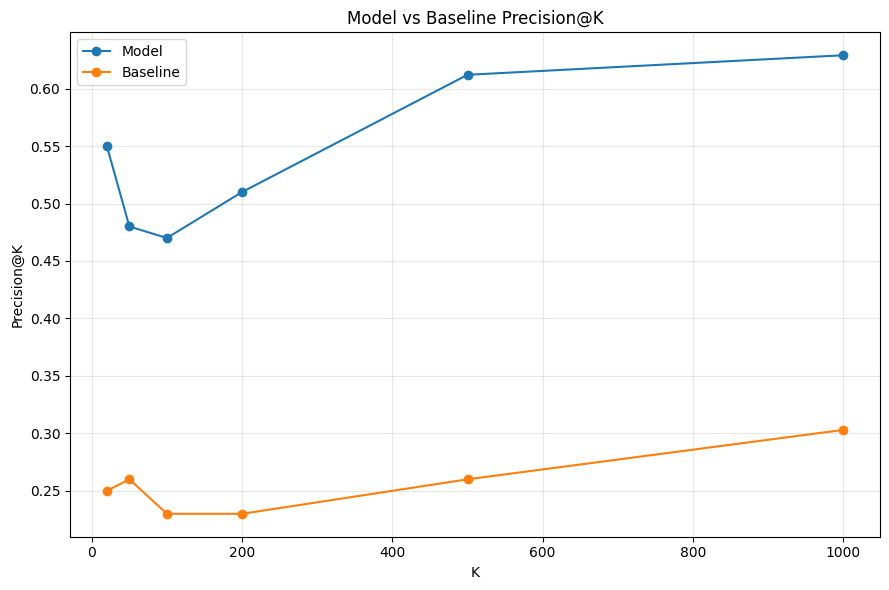

In [72]:
# ============================================================
# CAPSTONE — CELL 27
# Model vs baseline chart
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    results_df["K"],
    results_df["Model Precision"],
    marker="o",
    label="Model"
)

plt.plot(
    results_df["K"],
    results_df["Baseline Precision"],
    marker="o",
    label="Baseline"
)

plt.xlabel("K")
plt.ylabel("Precision@K")
plt.title("Model vs Baseline Precision@K")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

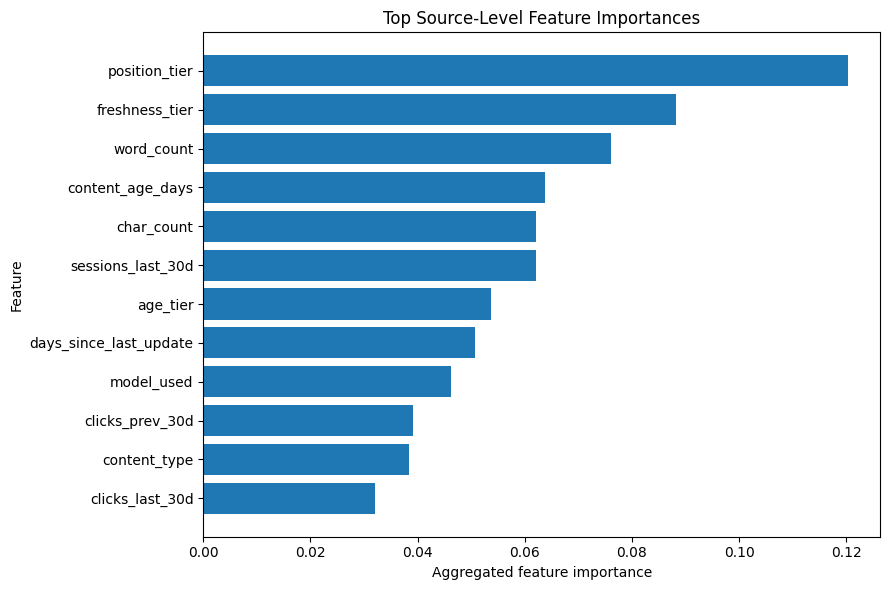

In [73]:
# ============================================================
# CAPSTONE — CELL 28
# Feature importance chart
# ============================================================

top_features = (
    source_importance
    .head(12)
    .sort_values(
        "importance"
    )
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["source_feature"],
    top_features["importance"]
)

plt.xlabel("Aggregated feature importance")
plt.ylabel("Feature")
plt.title("Top Source-Level Feature Importances")

plt.tight_layout()

plt.show()

In [74]:
# ============================================================
# CAPSTONE — CELL 29
# Create output directory
# ============================================================

outputs_path = os.path.join(
    repo_path,
    "work",
    "outputs"
)

os.makedirs(
    outputs_path,
    exist_ok=True
)

print("Output directory:")
print(outputs_path)

Output directory:
/content/flyrank-ml-starter/work/outputs


In [75]:
# ============================================================
# CAPSTONE — CELL 30
# Export paper tables
# ============================================================

results_file = os.path.join(
    outputs_path,
    "model_vs_baseline.csv"
)

importance_file = os.path.join(
    outputs_path,
    "feature_importance.csv"
)

queue_file = os.path.join(
    outputs_path,
    "ranked_action_queue.csv"
)

results_df.to_csv(
    results_file,
    index=False
)

source_importance.head(20).to_csv(
    importance_file,
    index=False
)

action_queue.head(1000).to_csv(
    queue_file,
    index=False
)

print("Saved:")
print(results_file)
print(importance_file)
print(queue_file)

Saved:
/content/flyrank-ml-starter/work/outputs/model_vs_baseline.csv
/content/flyrank-ml-starter/work/outputs/feature_importance.csv
/content/flyrank-ml-starter/work/outputs/ranked_action_queue.csv


In [76]:
# ============================================================
# CAPSTONE — CELL 31
# Export paper figures
# ============================================================

comparison_chart = os.path.join(
    outputs_path,
    "model_vs_baseline.png"
)

importance_chart = os.path.join(
    outputs_path,
    "feature_importance.png"
)


# Model vs baseline
plt.figure(figsize=(9, 6))

plt.plot(
    results_df["K"],
    results_df["Model Precision"],
    marker="o",
    label="Model"
)

plt.plot(
    results_df["K"],
    results_df["Baseline Precision"],
    marker="o",
    label="Baseline"
)

plt.xlabel("K")
plt.ylabel("Precision@K")
plt.title("Model vs Baseline Precision@K")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    comparison_chart,
    dpi=160,
    bbox_inches="tight"
)

plt.close()


# Feature importance
plt.figure(figsize=(9, 6))

plt.barh(
    top_features["source_feature"],
    top_features["importance"]
)

plt.xlabel("Aggregated feature importance")
plt.ylabel("Feature")
plt.title("Top Source-Level Feature Importances")

plt.tight_layout()

plt.savefig(
    importance_chart,
    dpi=160,
    bbox_inches="tight"
)

plt.close()

print("Charts saved:")
print(comparison_chart)
print(importance_chart)

Charts saved:
/content/flyrank-ml-starter/work/outputs/model_vs_baseline.png
/content/flyrank-ml-starter/work/outputs/feature_importance.png


In [77]:
# ============================================================
# CAPSTONE — CELL 32
# Reproducibility summary
# ============================================================

print("=" * 60)
print("REPRODUCIBILITY SUMMARY")
print("=" * 60)

print(
    "Random state:",
    RANDOM_STATE
)

print(
    "Dataset rows:",
    len(df)
)

print(
    "Dataset columns:",
    len(df.columns)
)

print(
    "Training rows:",
    len(train_df)
)

print(
    "Test rows:",
    len(test_df)
)

print(
    "Training clients:",
    train_df["client_id"].nunique()
)

print(
    "Test clients:",
    test_df["client_id"].nunique()
)

print(
    "Client overlap:",
    len(client_overlap)
)

print(
    "Test down base rate:",
    round(
        float(test_base_rate),
        4
    )
)

print("\nArtifacts:")
print("- model_vs_baseline.csv")
print("- feature_importance.csv")
print("- ranked_action_queue.csv")
print("- model_vs_baseline.png")
print("- feature_importance.png")

REPRODUCIBILITY SUMMARY
Random state: 42
Dataset rows: 30000
Dataset columns: 45
Training rows: 26619
Test rows: 3381
Training clients: 26
Test clients: 6
Client overlap: 0
Test down base rate: 0.525

Artifacts:
- model_vs_baseline.csv
- feature_importance.csv
- ranked_action_queue.csv
- model_vs_baseline.png
- feature_importance.png


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

In [78]:
# ============================================================
# CAPSTONE — CELL 33
# Final self-check
# ============================================================

checks = {
    "Dataset loaded": len(df) == 30000,

    "Target exists":
        "trend_direction" in df.columns,

    "Binary target created":
        "target_down" in df.columns,

    "41 features":
        len(feature_columns) == 41,

    "trend_direction excluded":
        "trend_direction" not in feature_columns,

    "trend_pct excluded":
        "trend_pct" not in feature_columns,

    "client_id excluded":
        "client_id" not in feature_columns,

    "No client overlap":
        len(client_overlap) == 0,

    "Model trained":
        hasattr(model, "predict_proba"),

    "Predictions generated":
        len(y_prob) == len(test_df),

    "Results generated":
        not results_df.empty,

    "Feature importance generated":
        not source_importance.empty,

    "Action queue generated":
        not action_queue.empty,

    "Results artifact exists":
        os.path.exists(results_file),

    "Importance artifact exists":
        os.path.exists(importance_file),

    "Queue artifact exists":
        os.path.exists(queue_file)
}

print("=" * 60)
print("CAPSTONE SELF-CHECK")
print("=" * 60)

all_passed = True

for check_name, passed in checks.items():

    status = "PASS" if passed else "FAIL"

    print(
        f"{status} — {check_name}"
    )

    if not passed:
        all_passed = False

print("=" * 60)

if all_passed:
    print("ALL CAPSTONE CHECKS PASSED")
else:
    print("SOME CAPSTONE CHECKS FAILED")

CAPSTONE SELF-CHECK
PASS — Dataset loaded
PASS — Target exists
PASS — Binary target created
PASS — 41 features
PASS — trend_direction excluded
PASS — trend_pct excluded
PASS — client_id excluded
PASS — No client overlap
PASS — Model trained
PASS — Predictions generated
PASS — Results generated
PASS — Feature importance generated
PASS — Action queue generated
PASS — Results artifact exists
PASS — Importance artifact exists
PASS — Queue artifact exists
ALL CAPSTONE CHECKS PASSED


In [79]:
# ============================================================
# CAPSTONE — CELL 34
# Final verified numbers
# ============================================================

print("=" * 70)
print("FINAL PAPER NUMBERS")
print("=" * 70)

print(
    f"Dataset: {len(df):,} rows / "
    f"{len(df.columns)} columns"
)

print(
    f"Training: {len(train_df):,} rows / "
    f"{train_df['client_id'].nunique()} clients"
)

print(
    f"Test: {len(test_df):,} rows / "
    f"{test_df['client_id'].nunique()} clients"
)

print(
    f"Client overlap: {len(client_overlap)}"
)

print(
    f"Test down base rate: "
    f"{test_base_rate:.4f} "
    f"({test_base_rate * 100:.2f}%)"
)

print("\nPrecision@K")
print("-" * 70)

for _, row in results_df.iterrows():

    print(
        f"@{int(row['K']):<4} "
        f"Model={row['Model Precision']:.4f} | "
        f"Baseline={row['Baseline Precision']:.4f} | "
        f"Improvement={row['Absolute Improvement']:.4f} | "
        f"Lift={row['Lift vs Baseline']:.2f}x"
    )

print("\nTop 10 source-level features")
print("-" * 70)

display(
    source_importance.head(10)
)

FINAL PAPER NUMBERS
Dataset: 30,000 rows / 45 columns
Training: 26,619 rows / 26 clients
Test: 3,381 rows / 6 clients
Client overlap: 0
Test down base rate: 0.5250 (52.50%)

Precision@K
----------------------------------------------------------------------
@20   Model=0.5500 | Baseline=0.2500 | Improvement=0.3000 | Lift=2.20x
@50   Model=0.4800 | Baseline=0.2600 | Improvement=0.2200 | Lift=1.85x
@100  Model=0.4700 | Baseline=0.2300 | Improvement=0.2400 | Lift=2.04x
@200  Model=0.5100 | Baseline=0.2300 | Improvement=0.2800 | Lift=2.22x
@500  Model=0.6120 | Baseline=0.2600 | Improvement=0.3520 | Lift=2.35x
@1000 Model=0.6290 | Baseline=0.3030 | Improvement=0.3260 | Lift=2.08x

Top 10 source-level features
----------------------------------------------------------------------


,source_feature,importance
0,position_tier,0.120271
1,freshness_tier,0.088178
2,word_count,0.076151
3,content_age_days,0.063856
4,char_count,0.062178
5,sessions_last_30d,0.062048
6,age_tier,0.053647
7,days_since_last_update,0.050662
8,model_used,0.046282
9,clicks_prev_30d,0.039175
